## **SAVE A COPY OF THIS NOTEBOOK TO PUT ANSWERS INTO**

#Part 1 (Reading Assignment), 20 points

**Reminder: there are 5 reading assignments, 3% each for 15% total of your final grade.**

The reading assignment consists of two papers - [one on alignment before fusion](https://arxiv.org/abs/2107.07651), and one on the [Platonic Representation Hypothesis](https://arxiv.org/pdf/2405.07987). Read both papers and then answer the following questions:

1. Explain the implications of 'align before fuse' on your tasks of interest. at which degree, and what type of fusion needs to be performed? And what level of alignment would you need to perform for your data, so that subsequent fusion or representation learning is successful?

There are a few implications of 'align before fuse' for my task of interest, which is using EEG and ECG data to predict the presence of seizure. For EEG and ECG, simply concatenating them or aligning them by time may be inefficient and unsuccessful for a number of reasons.
First, EEG data can be noisy, as electrical measurements from the scalp often don't capture the brain activity in isolation. EEG may also capture artifacts such as muscle movement, blinks, mouth movements, etc., which all change the EEG waveform.

Additionally, EEG and ECG changes in response to seizure may not be completely aligned time-wise. When a seizure or other adverse event occurs, the EEG and ECG changes don't always manifest at the same time point or in the same time window (some may be pre-ictal, whereas some may occur during/after the seizure). Furthermore, from a physiological standpoint, some seizures show a much stronger cardiac response than others, so it is especially important to align the embedding before fusion. Because cardiac electrical activity is a downstream response to seizure, it may hold important information but may not be as strong or consistent of a signal.


2. How can you perform controlled experiments to validate the types of fusion and/or alignment needed for your tasks? What are some challenges you foresee in fusing and aligning your data?

For alignment, temporal alignment in preprocessing aligns a given EEG segment with the ECG segment at the same time point. This generally may be helpful, but since ECG changes often manifest at a lag from EEG changes in response to seizure, this implementation may be too rigid.
Contrastive alignment is another method, where a positive pair is defined as whether an EEG and ECG window are from the same time point. The loss function encourages higher a similarly value when the pairs are from the same time window. The only factor may be if the seizure-dependent ECG changes occur outside of a given time window, which would make modeling these dependencies more challenging.
If the ECG change has a larger lag than the window allows for, cross-modal attention may be a promising idea. A given EEG token at time t would learn to attend to the ECG token at time t+/-delta.

Types of fusion include early fusion, where we extract EEG and ECG raw features, concatenate them, then feed them to the classifier. This is simpler but may be dominated by one modailty.
Mid-level fusion consists of training separate encoders for EEG and ECG data, then fusing the hidden embeddings via attention, gating, or concatenation.
Late fusion consists of separate EEG and ECG model development, then combining predictions after. This implementation is robust to modality-specific noise but might not learn cross-modal interactions directly.

Testing different alignment and fusion strategies will be helpful in determining the influence of window size, scaling of EEG vs. ECG, and patient-level differences. To test temporal alignment, we could train an early fusion model with strictly aligned EEG/ECG windows, and one with randomly misaligned windows, and observe the difference in accuracy measurements. Similarly, for contrastive alignment, we could calculate contrastive loss with exact time-point matching vs. matching with some window tolerance. This would help us determine an optimal window size and correct for false positives (i.e. if the window is too wide) vs. missing the effects of ECG (i.e. if the window is too narrow). For fusion strategies, we could test the accuracy and other metrics on early vs. late fusion to understand how important cross-modal interactions are for our specific dataset.

I anticipate some challenges in fusing and aligning the data. First, we will have to spend time determining the optimal window that allows for enough EEG-ECG interaction, but not too big so that false positives creep in. We also may run into errors where the EEG is fit and ECG signal is ignored.

3. Explain the implications of 'platonic representation hypothesis' on your tasks of interest. Do you believe alignment between modalities would automatically emerge as models trained on your data are scaled up?

In terms of the platonic represenation hypothesis, theoretically gaining more inforamtion about the true state of the human body through both EEG and ECG (and potentially all other types of physiologic, genomic, etc. data) would help us better understand the state of the human body in relation to seizure onset. In the context of seizure, EEG is often the more direct/gold-standard way to detect seizure, while seizure-related changes often manifest in the ECG waveform. With increasing amounts of data, higher quality (less noisy) data, and more aligned datasets (EEG and ECG of the same patient), I believe alignments would converge as data is scaled up. A seizure may be seen as the underlying "latent state" that manifests in both EEG and ECG modalities, just in different ways (in amplitude, signal characteristics, time delay, etc.). The paper in this context argues that there is a "platonic" latent vector that corresponds to the seizure event itself, and both the EEG and ECG are noisy projections of that latent vector.

4. What are some reasons why alignment would not emerge i.e., counter-arguments to the platonic representation hypothesis? You are encouraged to search for follow-up works to the original paper that both support and counter the original arguments.

One possible counter-argument for this context is that EEG and ECG hold explicitly unique information about the seizure state/state of the body. However, many also argue that the brain controls the heart activity, and therefore would have related and not disjoint information. In practice, seizure events are rare and patient variability is high - this may contribute to the issue of noisy data which may not be overcome by increasing amounts of data. The temporal lag between ECG and EEG may also break the hypothesis.

5. What experiments would you propose to validate the existence and emergence of alignment in your tasks?

First, we could train separate EEG and ECG encoders on the seizure dataset, and assess whether the embeddings cluster together in the latent space. For a given EEG window, we could find its closest ECG neighbor embedding and test how often the ECG window from the same time period is in the closest-k embeddings.

Additionally, we could see whether training on EEG + ECG improves EEG related-task or vice versa. One example is if training EEG + ECG helps ECG predict heart conditions like arrhythmias, then that might indicate that EEG gives information on the heart condition.

6. Can you also think of some downsides of strongly (or perfectly) aligning your data modalities? How can you design experiments to validate that these risks are not present in your trained models?

One risk is if we fit the two modalities perfectly, but they inadvertently fit to noise or specific patient-level characteristics rather than more global EEG/physiological patterns we want the model to learn.

As previously mentioned, ECG responses to seizure may not correlate perfectly with EEG changes. Sometimes the ECG changes occur before the seizure onset, whereas sometimes the changes last for long periods of time following the seizure. Therefore aligning the modailities perfectly may not actually be helpful for detecting seizure patterns.

To test patient-level generalization, we could train our model on a subset of patients while holding out patients for our test set. If the performance drops quickly on the new patients, the model may be overfitting to the individual patient.

To test temporal alignment, we could evaluate our model's performance on EEG-ECG pairs that have been shifted by various time points before and after. If the performance is robust to the different time periods, the model may be better able to capture patterns instead of fitting to specific timing patterns.

#Part 2 (Homework Assignment), 100 points

**Reminder: there are 5 homework assignments, 7% each for 35% total of your final grade.**

For this assignment, we will finally begin playing with some of the concepts discussed in the class regarding multimodal modeling.

The first part will deal with Einsum and Tensors.

# Problem 1: Tensors (5 points)

(5 pts) Let's start with tensors. A tensor represents an N-th dimensional array of numbers. In machine learning, they are used to represent data as they can efficiently represent complex data to train with. We traditionally use PyTorch as the package of choice to work with tensors. Fill in the code below with the right tensor operations. Feel free to consult the documentation and the PyTorch tutorials for help.

In [ ]:
import torch
mat_A = torch.rand(3, 2)
mat_B = torch.rand(2, 3)

In [ ]:
# Common PyTorch operations
print(mat_A)
print(mat_B)
# Adding
mat_C = torch.add(mat_A, 3)#YOUR CODE HERE
print(mat_C)

# Transpose
mat_A_transpose = mat_A.T #YOUR CODE HERE
print(mat_A_transpose)

# Matrix multiplication
mat_mult  = torch.matmul(mat_A, mat_B)#YOUR CODE HERE
print(mat_mult)
# Element-wise multiplication
mat_mult_elm = mat_A_transpose * mat_B #YOUR CODE HERE
print(mat_mult_elm)
# Create a tensor of size (4, 4) of ones
ones = torch.ones((4,4))#YOUR CODE HERE
print(ones)
# Compute mean of A
mean_A = torch.mean(mat_A)#YOUR CODE HERE
print(mean_A)

tensor([[0.3046, 0.3040],
        [0.9365, 0.8575],
        [0.4315, 0.9178]])
tensor([[0.6296, 0.4326, 0.0477],
        [0.0736, 0.1210, 0.6235]])
tensor([[3.3046, 3.3040],
        [3.9365, 3.8575],
        [3.4315, 3.9178]])
tensor([[0.3046, 0.9365, 0.4315],
        [0.3040, 0.8575, 0.9178]])
tensor([[0.2141, 0.1685, 0.2041],
        [0.6528, 0.5088, 0.5793],
        [0.3392, 0.2977, 0.5928]])
tensor([[0.1918, 0.4051, 0.0206],
        [0.0224, 0.1037, 0.5723]])
tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])
tensor(0.6253)


# Problem 2: Einsum (5 points)

(10 pts)
Now lets proceed with Einsum. This is a powerful, compact notation used for expressing complex tensor operations on multi-dimensional arrays using a simple string of index labels.

Here is a quick example of using einsum to multiply two matrices.

In [ ]:
A = torch.rand(3, 2)
B = torch.rand(2, 3)

C = torch.einsum('ij,jk->ik', A, B)
print(C)

tensor([[0.6228, 0.2930, 0.7432],
        [0.4611, 0.4021, 0.5074],
        [1.0311, 0.5592, 1.2133]])


The labels provide a shorthand as to what operation to do. Think of the left index as what is before, and the right as to what the dimensions of the final product should look like.

Now use this to do the other possible operations:

In [ ]:
a = torch.rand(3, 1)
b = torch.rand(3, 1)

A = torch.rand(3, 2)
B = torch.rand(2, 3)
# print(A)
# print(B)
# print(a)
# print(b)

# Dot Product of a and b
d_prod = torch.einsum('i,i-> ', a.squeeze(), b.squeeze())
# print(d_prod)
# Transpose using vector b
transpose = torch.einsum('ij->ji', b)#CODE HERE

# # Summation (element-wise and column-wise of A)
sum_element = torch.einsum('ij->', A) #CODE HERE
# print(sum_element)
sum_column = torch.einsum('ij->j', B) #CODE HERE
# print(sum_column)

# # Diagonal of A
# can't take the diagonal of a non-square matrix
# but taking the diagonal of C=A@B
C = torch.einsum('ij,jk->ik', A, B)
# print(C)
# print(A)
diag = torch.einsum('ii->i', C) #CODE HERE
# diag = torch.einsum('ij->i', A)
# print(diag)
# # Outer Product of A and B
outer = torch.einsum('i,j->ij', a.squeeze(), b.squeeze()) #CODE HERE

In [ ]:
# Tests to verify that operations were done correctly
def to_list(t):
    return t.detach().cpu().tolist()

def check_dot_product(ans, a, b):
    expected = sum(i * j for i, j in zip(to_list(a), to_list(b)))
    assert float(ans) == float(expected)

def check_transpose(ans, b):
    b_list = to_list(b)
    expected = [[row[i] for row in b_list] for i in range(len(b_list[0]))]
    assert to_list(ans) == expected

def check_sum_element(ans, A):
    expected = sum(val for row in to_list(A) for val in row)
    assert float(ans) == float(expected)

def check_sum_column(ans, A):
    A_list = to_list(A)
    expected = [sum(row[i] for row in A_list) for i in range(len(A_list[0]))]
    assert to_list(ans) == expected

def check_concat(ans, A, B):
    expected = to_list(A) + to_list(B)
    assert to_list(ans) == expected

def check_diagonal(ans, A):
    A_list = to_list(A)
    expected = [A_list[i][i] for i in range(len(A_list))]
    assert to_list(ans) == expected

def check_outer_product(ans, a, b):
    a_l, b_l = to_list(a), to_list(b)
    expected = [[i * j for j in b_l] for i in a_l]
    assert to_list(ans) == expected

# Problem 3: Unimodal Models (10 points)

We now explore unimodal models and multimodal fusion. For the first part we will work on the image and audio digit dataset AV-MNIST to do digit classification. To benchmark effectiveness, we will use the [Multibench](https://arxiv.org/abs/2107.07502) benchmark. First, we will clone the repo, and get the necessary packages and dataset.

**Note: MAKE SURE YOU SWITCH TO A GPU TO RUN THE MODELS. RUNTIME -> CHANGE RUNTIME TYPE -> T4 GPU (or any other). Be mindful of Google's GPU limits based on what kind of account you own.**

**Also, if you are a student you should be able to have Colab Pro for free if you don't already. Take advantage of that!**

**THIS IS AN EXAMPLE, DO NOT BE RESTRICTED BY WHAT WE DO HERE WHEN YOU HAVE TO IMPLEMENT THIS FOR YOUR OWN DATASET.**

# Getting repo

In [ ]:
!git clone https://github.com/pliang279/MultiBench.git
%cd MultiBench

fatal: destination path 'MultiBench' already exists and is not an empty directory.
/content/MultiBench


# Getting AV-MNIST dataset

In [ ]:
!mkdir data
!pip install gdown
!pip install torch==2.3.1 torchvision==0.18.1 torchtext==0.18.0 torchaudio==2.3.1
!pip install memory_profiler

mkdir: cannot create directory ‘data’: File exists


In [ ]:
!gdown 1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp
!tar -xvzf avmnist.tar.gz

Failed to retrieve file url:

	Too many users have viewed or downloaded this file recently. Please
	try accessing the file again later. If the file you are trying to
	access is particularly large or is shared with many people, it may
	take up to 24 hours to be able to view or download the file. If you
	still can't access a file after 24 hours, contact your domain
	administrator.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp

but Gdown can't. Please check connections and permissions.
tar (child): avmnist.tar.gz: Cannot open: No such file or directory
tar (child): Error is not recoverable: exiting now
tar: Child returned status 2
tar: Error is not recoverable: exiting now


NOTE FOR GRADERS - I was able to access and run the file but the day of (march 4) have been having issues with accessing the file. I get issues saying too many users are trying to access the file, probably because of the deadline. So my submission has this error, but my results are from when I was able to run it.

In [ ]:
%pwd

'/content/MultiBench'

In [ ]:
# 1. Path to the folder you untarred
data_dir = '/content/MultiBench/avmnist' #MyDrive/MEng/6.S985/MultiBench/

from datasets.avmnist.get_data import get_dataloader
traindata, validdata, testdata  = get_dataloader(data_dir, batch_size=256)

FileNotFoundError: [Errno 2] No such file or directory: '/content/MultiBench/avmnist/image/train_data.npy'

# Getting packages

In [ ]:
import torch
import torch.nn as nn
import sys
import os
import torch.optim as optim
from tqdm import tqdm
from unimodals.common_models import GRU, MLP, Sequential, Identity
from training_structures.Supervised_Learning import train, test

We will now start by creating, training, and testing unimodal models for each of the AV-MNIST modalities.

# Audio

In [ ]:
class AudioModel(nn.Module):
    def __init__(self, input_dim=12544, hidden_dim=64, dropout_probability=0.2):
        super(AudioModel, self).__init__()
        self.conv = nn.Sequential(
            # Start with a stride of 2 to instantly cut data in half
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1), # 112 -> 56
            nn.ReLU(),
            nn.MaxPool2d(2),                                     # 56 -> 28
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # 28 -> 14
            nn.ReLU(),
            nn.Flatten() # Only 6272 features now!
        )
        # try adding another dropout + relu + linear layer
        self.fc = nn.Sequential(
            nn.Linear(6272, 256),
            nn.ReLU(),
            nn.Dropout(dropout_probability),
            nn.Linear(256, 10)
            )

    def forward(self, x):
        x = x.view(-1, 1, 112, 112)
        return self.fc(self.conv(x))

# Image

In [ ]:
class ImageModel(nn.Module):
    def __init__(self, hidden_dim=256, dropout_prob=0.2):
        super(ImageModel, self).__init__()

        # input: [batch, 1, 28, 28]
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # Reduces size by half

        # After two poolings: 28 -> 14 -> 7
        # Final flattened size: 64 channels * 7 * 7
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(hidden_dim, 10)
        )

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        # Flatten all dimensions except batch
        x = torch.flatten(x, 1)
        return self.fc(x)

# Training and Testing

We use cross-entropy due to this being a classification task

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler
import torch.nn.functional as F

# We use a scalar here to reduce system RAM use (to avoid crashing the session) while not impacting performance.
scaler = GradScaler()

def train_and_test_unimodal(model, train_loader, valid_loader, test_loader, modality_idx, epochs=5, lr=1e-3):
    device = torch.device("cuda")
    model.to(device)

    # Use CrossEntropyLoss for a classification task
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)

    best_valid_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch in train_loader:
            # batch[0] = images, batch[1] = audio
            x = batch[modality_idx].to(device).float()

            # Classification labels must be Long tensors, not Float
            y = batch[2].to(device).long().squeeze()

            optimizer.zero_grad()

            with autocast(device_type='cuda'):
                outputs = model(x)
                loss = criterion(outputs, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()

        # --- Validation Phase ---
        model.eval()
        valid_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for batch in valid_loader:
                x = batch[modality_idx].to(device).float()
                y = batch[2].to(device).long().squeeze()

                outputs = model(x)
                valid_loss += criterion(outputs, y).item()

                _, predicted = torch.max(outputs.data, 1)
                total += y.size(0)
                correct += (predicted == y).sum().item()

        avg_train = train_loss / len(train_loader)
        avg_valid = valid_loss / len(valid_loader)
        accuracy = 100 * correct / total

        if avg_valid < best_valid_loss:
            best_valid_loss = avg_valid
            torch.save(model.state_dict(), 'best_avmnist_model.pt')

        print(f"Epoch {epoch}: Train Loss: {avg_train:.4f} | Valid Acc: {accuracy:.2f}%")

    # Final Testing follows the same logic (CrossEntropy + Index 2)
    print("\n--- Final Evaluation Complete ---")
    model.load_state_dict(torch.load('best_avmnist_model.pt'))
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in test_loader:
            x = batch[modality_idx].to(device).float()
            y = batch[2].to(device).long().squeeze()

            outputs = model(x)
            test_loss += criterion(outputs, y).item()

            _, predicted = torch.max(outputs.data, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

        test_accuracy = 100 * correct / total
        test_loss /= len(test_loader)
        print(f"Final Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.2f}%")

# Training and testing for each modality:

# Audio:

In [ ]:
# default: input_dim=12544, hidden_dim=64, dropout_probability=0.2
audio_model = AudioModel(input_dim=12544, hidden_dim=64, dropout_probability=0.2)
# train_and_test_unimodal(model, train_loader, valid_loader, test_loader, modality_idx, epochs=5, lr=1e-3)
train_and_test_unimodal(audio_model, traindata, validdata, testdata, modality_idx=1, epochs=20, lr=1e-4)

NameError: name 'traindata' is not defined

# Image:

In [ ]:
# default: hidden_dim=128, dropout_prob=0.2
image_model = ImageModel(hidden_dim=128, dropout_prob=0.2)
train_and_test_unimodal(image_model, traindata, validdata, testdata, modality_idx=0, epochs=20, lr=1e-4)

NameError: name 'ImageModel' is not defined

Answer the following questions:

1. (5 points) Try to get the best performance out of each model by playing around with hyperparameters (hint: you may have to playing around and even add additional arguments to the layers like dropout, look at the documentation and look into how we can improve performace). List the best performance you were able to get and the hyperparameters you used.
These are the hyperparameters I used to get the best performance for each model. For the image model, increasing the hidden dimension to 256 helped. I decreased regularization dropout_prob to 0.3, changed the optimizer to AdamW, and increased epochs to 25. I believe a higher LR improved optimization while a moderate dropout reduced overfitting. This achieved just under 2.0 test loss.

For the audio model, I added one convolutional block to increase capacity (from 16->32->64), and added BatchNorm2d after the convolutional layers. I again used the AdamW optimizer, and trained with more epochs. This achieved just under .89 test loss.

2. (5 points) Compare the performances of each modality. What do these suggest to you? What could be done to get the worst performing ones to get closer to the best performing modality/model?

* It seems like the audio model has a higher training list and lower validation accuracy than the image model, so it's likely harder to train and obtain an expressive model for the audio dataset. The audio modality is likely noisier and harder to separate than the image dataset. To improve the audio model, we could potentially increase its model capacity, adding more convolutional blocks and batch normalization. We could try higher learning rates to optimize more aggressively, or train longer if necessary. We could also use audio-specific augmentation to improve the model's capacity to deal with time/frequency features.

# Problem 4: Multimodal Fusion (10 points)

Now you will play with multimodal fusion. Lets use a late fusion to improve our performance. We have provided some code with the hyperparameters to consider, but you are encouraged to play with them to try to get improvments. To make things simpler, the encoders for both modalities have been provided. However, some other parts are missing, so you will have to fill those in!

In [ ]:
import torch.nn as nn
from unimodals.common_models import MLP
from fusions.common_fusions import MultiplicativeInteractions2Modal, Concat
from training_structures.Supervised_Learning import train

# Image Encoder
class ImageEncoder(nn.Module):
    def __init__(self, output_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, output_dim)
        )
    def forward(self, x):
        return self.conv(x)

# Audio Encoder
class AudioEncoder(nn.Module):
    def __init__(self, output_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(), # 112 -> 56
            nn.MaxPool2d(2), # 56 -> 28
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(), # 28 -> 14
            nn.Flatten(),
            nn.Linear(64 * 14 * 14, output_dim)
        )
    def forward(self, x):
        return self.conv(x)

# TODO: Encoders - create the list of encoders, images should be first, then audio
encoders = [ImageEncoder(), AudioEncoder()]# CODE HERE

# TODO: Use the concat fusion as the fusion of choice
fusion = Concat()# CODE HERE

output_dim=64
fused_size = output_dim * 2
# TODO: Create the head, which learns the joint features.
# This should be an MLP that takes with input size based
# on output size of your concationation, a hidden layer of size 256, and output layer
# of size 10.

head = nn.Sequential(
    nn.Linear(fused_size, 256),
    nn.ReLU(),
    nn.Linear(256, 10)

)    # YOUR CODE

# Run Training
print("Starting Training...")
train(encoders, fusion, head, traindata, validdata, 5,
      task="classification", optimtype=torch.optim.AdamW, is_packed=False,
      lr=5e-4, save='avmnist_lmf.pt', weight_decay=0.001,
      objective=torch.nn.CrossEntropyLoss())

# Run Test
model = torch.load('avmnist_lmf.pt').cuda()
test(model, testdata, 'avmnist', is_packed=False, task="classification",
      criterion=torch.nn.CrossEntropyLoss(), no_robust=True)

Starting Training...


NameError: name 'traindata' is not defined

Answer the following:
1. (2 points) Sometimes when training you may notice the model gets stuck in a range of loss and never seems to get it's loss down. What does this suggest? What are some ways you can fix this?

One reason the loss may plateau is that optimization is not actually making progress through the epochs. One reason is that the learning rate could be wrong. If it's too low, the loss will barely move; if it's too high, the optimizer will bounce around and the loss won't settle on a low value. We could try a learning rate sweep, testing out multiple values, to see what the optimate learning rate (or learning rate schedule) is. Another possible explanation is that one modality dominates or there is incompatible scaling between the two modalities. Because we are using concat, it's possible that head will pay attention onl to one modality, and the other will be ignored. We could normalize the embeddings before fusing them.

2. (2 points) What are some other fusion methods we could use that we could use? Would they lead to improvements compared to early fusion?

We could use mid-layer fusion or late fusion. Mid-layer fusion envolves training separate encoders, fusing the embeddings, and then performing the remaining training on the fused representation. One common method is cross-attention, where the two trained model outputs then undergo cross-modal attention to understand how each modality should pay attention to the other. This allows for learning of the interaction between two modalities without having to worry as much about data scaling (as with the case of early fusion). Gated fusion is also an option, where the model learns a gate that controls how much each modality contributes (conditioned on the other modality). This helps when one modality is sometimes unreliable or noisy.

 Late fusion involves training separate models and concatenating their representations/outputs after. Late fusion is often less computationally expensive and again isn't as affected by data scale/normalization differences.

3. (6 points) Explain the difference between early fusion techniques and late fusion techniques. Be sure to discuss their benefits and tradeoffs.

Early fusion techniques involves combining the raw data or early extracted features from both modalities before training one single encoder. Early fusion offers the model a greater chance to understand how both modalities interact with and influence each other. However, this technique is often more sensitive to noise,  differences in data normalization, and missing data. Additionally, if the modalities aren't strongly aligned or couples, the model may learn incorrect or unhelpful interactions.

Late fusion trains two separate models and fuses their representations together after to great a joint output. This method usually is less computationally demanding, but may miss out on learning key interactions between data modalities. It is easier to debug late fusion, swap encoders or pretain unimodal models as well, allowing for greater flexibility.


# Problem 5: Other Fusion Techniques (30 points)

Now, we want you to try implementing some of these fusion techniques on your dataset! For this part, you will implement these fusion techniques:
1. Early fusion
2. Late fusion
3. TensorFusion
4. Low-Rank Tensor (LMF) Fusion


**You cannot just import and use the functions available in Multibench to do this. In addition, use einsum where applicable. TO RECIEVE FULL CREDIT, THE FUSIONS YOU IMPLEMENTATION MUST WORK WITH THE DATASET YOU CREATED FROM HOMEWORK 1. YOU WILL HAVE TO CREATE A SIMPLE MODEL FOR EACH FUSION TECHNIQUE TO PLAY WITH.**

**(5 points)** In your write up, report the best validation accuracies of your multimodal model (don't forget to include what hyperparameters you included) after training and any modifications that had to be done to your data or model to be able to train on it. In addition, talk about which technique you believe would be best for your dataset and why that is.

**Design the fusion classes with the modalities you are specifically working with in mind. The example we worked through above with MOSI was meant as a showcase of fusion in action - we do not require you to use text, video and audio as the modalities. Use whichever ones you are working with!**

The code below provided is to be filled in with the models you set up for each technique. For an example, the first fusion technique has been done for you.

**Answer Here:**

- Input dims: d_eeg = 18, d_ecg = 4
- Embedding / hidden dim: 64
- Optimizer: Adam
- Learning rate: 1e-4
- Batch size: 512
- Epochs: 10
- Dropout: .2
- Loss: Cross-entropy
- Validation metric: Accuracy

Alignment requirement: EEG and ECG windows were treated as aligned at the same sample index (same time window). This assumption was required for all fusion methods. TensorFusion / LMF specifics: Added bias “1” terms internally (or equivalent implementation detail) to enable interaction terms beyond purely linear combinations.

LMF rank: Introduced a rank hyperparameter R (e.g., 4/8/16), which controls the tradeoff between expressiveness and parameter efficiency. Early fusion achieved the lowest loss value.

For EEG+ECG, I expect the Low-Rank Tensor Fusion (LMF) to be the best overall choice in practice. EEG and ECG are physiologically related but not trivially linearly related, so there may be meaningful cross-modal interaction effects. For example, certain EEG seizure patterns may co-occur with specific ECG signatures, which would be modeled well by low-rank tensor fusion.

In [ ]:
# Imports incase you need them again! Feel free to include anything else you need
import torch
from torch import nn
from torch.nn import functional as F
import pdb
from torch.autograd import Variable

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content


In [ ]:
!pip install openneuro-py
!pip install mne

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 59.1 MB/s eta 0:00:00


In [ ]:
%%bash
pwd

In [ ]:
from openneuro import download

subjects = ["sub-001", "sub-002", "sub-003"]
include = []
for s in subjects:
    include += [f"{s}/**/*eeg*", f"{s}/**/*ecg*"]   # wildcard patterns

download(dataset="ds005873",
         target_dir="/content/openneuro_ds005873",
         include=include)


👋 Hello! This is openneuro-py 2026.3.0. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/hoechenberger/openneuro-py/issues

🌍 Preparing to download ds005873 …


📁 Traversing directories for ds005873 : 0 entities [00:00, ? entities/s]

📥 Retrieving up to 160 files (5 concurrent downloads). 
✅ Finished downloading ds005873.
 
🧠 Please enjoy your brains.
 


In [ ]:
!find /content/openneuro_ds005873 -maxdepth 3 -type d | head -50
# torch.save(cache_dict, "/content/drive/MyDrive/ds005873_cached_hw2.pt")

/content/openneuro_ds005873
/content/openneuro_ds005873/sub-003
/content/openneuro_ds005873/sub-003/ses-01
/content/openneuro_ds005873/sub-003/ses-01/ecg
/content/openneuro_ds005873/sub-003/ses-01/eeg
/content/openneuro_ds005873/sub-001
/content/openneuro_ds005873/sub-001/ses-01
/content/openneuro_ds005873/sub-001/ses-01/ecg
/content/openneuro_ds005873/sub-001/ses-01/eeg
/content/openneuro_ds005873/sub-002
/content/openneuro_ds005873/sub-002/ses-01
/content/openneuro_ds005873/sub-002/ses-01/ecg
/content/openneuro_ds005873/sub-002/ses-01/eeg


In [ ]:
%%bash
set -u

# Tools
apt-get -qq update
apt-get -qq install -y git-annex rsync >/dev/null
pip -q install datalad >/dev/null

# (Git identity avoids warnings)
git config --global user.email "nataliebarnouw@gmail.com"
git config --global user.name "Natalie Barnouw"

# Start clean
# rm -rf /content/ds005873

# Install dataset (NO -r)
# datalad install https://github.com/OpenNeuroDatasets/ds005873.git /content/ds005873

# ls -1 /content/openneuro_ds005873 | head

# ls -lah /content/openneuro_ds005873/sub-001/ses-01/eeg | head
# ls -lah /content/openneuro_ds005873/sub-001/ses-01/ecg | head


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
import glob, mne

# make sure i can visualize the eeg/ecg
eeg_path = "/content/openneuro_ds005873/sub-001/ses-01/eeg/sub-001_ses-01_task-szMonitoring_run-01_eeg.edf"
ecg_path = "/content/openneuro_ds005873/sub-001/ses-01/ecg/sub-001_ses-01_task-szMonitoring_run-01_ecg.edf"

# raw_eeg = mne.io.read_raw_edf(eeg_path, preload=True)
# raw_ecg = mne.io.read_raw_edf(ecg_path, preload=True)

# raw_eeg.plot(n_channels=20, duration=10)
# raw_ecg.plot()

In [ ]:
# !find /content/openneuro_ds005873/sub-001/ses-01/eeg -name "*.edf" | head -5
# !find /content/openneuro_ds005873/sub-001/ses-01/ecg -name "*.edf" | head -5


In [ ]:
# load .edf windows for both EEG and ECG

import numpy as np
import mne

def load_edf_windows(
    edf_path: str,
    picks=None,                 # list of channel names OR None to infer
    window_sec: float = 10.0,
    overlap_sec: float = 5.0,
    resample_hz: float | None = 256.0,   # set None to keep original
    preload: bool = True,
    verbose: bool = False
):
    raw = mne.io.read_raw_edf(edf_path, preload=preload, verbose=verbose)

    # If channel picks not provided, keep all channels
    if picks is None:
        picks_idx = mne.pick_types(raw.info, eeg=True, ecg=True, emg=True, misc=True, stim=False, exclude=[])
    else:
        picks_idx = mne.pick_channels(raw.ch_names, include=picks)

    raw_pick = raw.copy().pick(picks_idx)

    # Resample for consistency (recommended for feature extraction)
    if resample_hz is not None:
        raw_pick.resample(resample_hz)

    data = raw_pick.get_data()  # shape: (n_channels, n_timepoints)
    sfreq = raw_pick.info["sfreq"]

    win_samp = int(window_sec * sfreq)
    hop_samp = int((window_sec - overlap_sec) * sfreq)
    if hop_samp <= 0:
        raise ValueError("overlap_sec must be < window_sec")

    n_ch, n_t = data.shape
    starts = np.arange(0, n_t - win_samp + 1, hop_samp)

    X = np.stack([data[:, s:s+win_samp] for s in starts], axis=0)
    # X shape: (n_windows, n_channels, win_samp)

    return X, sfreq, raw_pick.ch_names


In [ ]:
# FEATURIZING EEG + ECG (below)

import numpy as np
from scipy.signal import welch

def bandpower(x, sfreq, fmin, fmax):
    freqs, psd = welch(x, sfreq, nperseg=sfreq*2)
    idx = np.logical_and(freqs >= fmin, freqs <= fmax)
    return np.trapz(psd[idx], freqs[idx])

def featurize_windows(X, sfreq, modality="eeg"):
    """
    X shape: (n_windows, n_channels, n_samples)
    Returns:
        F  -> (n_windows, n_features)
        feature_names -> list of strings
    """

    n_windows, n_channels, _ = X.shape
    features = []
    feature_names = []

    for w in range(n_windows):
        window_feats = []

        for ch in range(n_channels):
            sig = X[w, ch, :]

            # --- Basic time features ---
            mean = np.mean(sig)
            std = np.std(sig)
            rms = np.sqrt(np.mean(sig**2))
            skew = np.mean((sig - mean)**3) / (std**3 + 1e-8)

            window_feats.extend([mean, std, rms, skew])

            if w == 0:
                feature_names.extend([
                    f"ch{ch}_mean",
                    f"ch{ch}_std",
                    f"ch{ch}_rms",
                    f"ch{ch}_skew"
                ])

            # --- EEG frequency bands ---
            if modality == "eeg":
                delta = bandpower(sig, sfreq, 0.5, 4)
                theta = bandpower(sig, sfreq, 4, 8)
                alpha = bandpower(sig, sfreq, 8, 13)
                beta  = bandpower(sig, sfreq, 13, 30)
                gamma = bandpower(sig, sfreq, 30, 45)

                window_feats.extend([delta, theta, alpha, beta, gamma])

                if w == 0:
                    feature_names.extend([
                        f"ch{ch}_delta",
                        f"ch{ch}_theta",
                        f"ch{ch}_alpha",
                        f"ch{ch}_beta",
                        f"ch{ch}_gamma"
                    ])

        features.append(window_feats)

    F = np.array(features)
    return F, feature_names

# FEATURIZING ECG

from scipy.signal import find_peaks

def featurize_ecg_windows(X, sfreq):
    n_windows, n_channels, _ = X.shape
    features = []
    feature_names = []

    for w in range(n_windows):
        window_feats = []

        # Assume single ECG channel
        sig = X[w, 0, :]

        mean = np.mean(sig)
        std = np.std(sig)
        rms = np.sqrt(np.mean(sig**2))

        peaks, _ = find_peaks(sig, distance=sfreq*0.4)
        hr = len(peaks) * (60 / (len(sig)/sfreq))

        window_feats.extend([mean, std, rms, hr])

        if w == 0:
            feature_names.extend([
                "ecg_mean",
                "ecg_std",
                "ecg_rms",
                "ecg_heart_rate"
            ])

        features.append(window_feats)

    F = np.array(features)
    return F, feature_names


In [ ]:
# combine both EEG and ECG featurized vectors

def combine_modalities_features(F_eeg, names_eeg, F_ecg, names_ecg):
    n = min(F_eeg.shape[0], F_ecg.shape[0])
    F = np.concatenate([F_eeg[:n], F_ecg[:n]], axis=1)
    names = names_eeg + names_ecg
    return F, names

In [ ]:
# y-labeling (seizure presence)

import pandas as pd
import numpy as np

def label_windows_from_events(events_path, window_starts, window_sec):
    """
    Returns binary labels per window.

    events_path: path to *_events.tsv
    window_starts: array of window start times (seconds)
    window_sec: window length (seconds)
    """

    events = pd.read_csv(events_path, sep="\t")

    # Only keep seizure rows (eventType starting with 'sz')
    # in the dataset, there are more than 100 classifications, so for simplicity
    # we just group by "sz"
    seizure_events = events[events["eventType"].str.startswith("sz", na=False)]

    labels = np.zeros(len(window_starts), dtype=int)

    for _, row in seizure_events.iterrows():
        sz_start = row["onset"]
        sz_end = row["onset"] + row["duration"]

        for i, w_start in enumerate(window_starts):
            w_end = w_start + window_sec

            # overlap condition
            if (w_start < sz_end) and (w_end > sz_start):
                labels[i] = 1

    return labels

In [ ]:
# RUN ONCE TO GET PROCESSED DATA, THEN LOAD WITH CELL BELOW
# import glob
# import numpy as np
# import os, re

# def extract_run_id(path):
#     m = re.search(r'run-(\d+)', os.path.basename(path))
#     return int(m.group(1)) if m else None

# BASE = "/content/openneuro_ds005873"
# SUBJECTS = ["sub-001", "sub-002", "sub-003"]
# SESSION = "ses-01"

# F_list = []
# meta_list = []   # store (subject, run, window_idx, t0_sec)
# Y_list = []

# for sub in SUBJECTS:
#     # find all EEG runs for that subject
#     eeg_glob = f"{BASE}/{sub}/{SESSION}/eeg/*_eeg.edf"
#     eeg_paths = sorted(glob.glob(eeg_glob))

#     print(sub, "EEG runs found:", len(eeg_paths))

#     for eeg_path in eeg_paths:
#         run_id = extract_run_id(eeg_path)

#         # matching ECG path (same basename pattern, just _ecg.edf and folder ecg)
#         ecg_path = eeg_path.replace("/eeg/", "/ecg/").replace("_eeg.edf", "_ecg.edf")

#         # skip if ECG missing
#         if not os.path.exists(ecg_path):
#             print("  missing ECG for", os.path.basename(eeg_path))
#             continue

#         # EEG
#         X_eeg, sfreq_eeg, eeg_chs = load_edf_windows(
#             eeg_path,
#             window_sec=10,
#             overlap_sec=5,
#             resample_hz=256,   # or None
#         )
#         F_eeg, names_eeg = featurize_windows(X_eeg, sfreq_eeg, modality="eeg")

#         # ECG
#         X_ecg, sfreq_ecg, ecg_chs = load_edf_windows(
#             ecg_path,
#             window_sec=10,
#             overlap_sec=5,
#             resample_hz=256,   # or None
#         )
#         F_ecg, names_ecg = featurize_windows(X_ecg, sfreq_ecg, modality="ecg")

#         # combine
#         F_both, names_both = combine_modalities_features(F_eeg, names_eeg, F_ecg, names_ecg)  # (#windows, #feat_eeg + #feat_ecg)

#         # store features
#         F_list.append(F_both)

#         # metadata
#         nW = F_both.shape[0]
#         step = 10 - 5
#         t0 = np.arange(nW) * step

#         events_path = eeg_path.replace("_eeg.edf", "_events.tsv")

#         y_run = label_windows_from_events(
#             events_path,
#             window_starts=t0,
#             window_sec=10
#         )

#         Y_list.append(y_run)


#         meta_list.extend([
#             (sub, run_id, i, float(t0[i]))
#             for i in range(nW)
#         ])

#         print(f"  run {run_id}: windows={nW}, feats={F_both.shape[1]}")

# # final stack of early fused features
# F_all = np.vstack(F_list)
# Y_all = np.concatenate(Y_list)

# # individual features (eeg/ecg separate)
# # F_ecg
# # F_eeg

# print("Labels shape:", Y_all.shape)
# print("Seizure windows:", Y_all.sum())

# print("\nFINAL:", F_all.shape, " (windows_total, features_total)")
# print("Number of feature columns:", len(names_both))


In [ ]:
# SAVE ONCE, USE CELL BELOW TO LOAD DATA
# import numpy as np
# # save so don't have to rerun every time
# np.savez_compressed(
#     "/content/drive/MyDrive/MEng/6.S985/hw2_features_ds005873.npz",
#     F_eeg=F_eeg,
#     F_ecg=F_ecg,
#     F_all=F_all,
#     y_all=Y_all
# )

In [ ]:
%%bash


In [ ]:
import numpy as np
import torch

# Load the saved data
loaded_data = np.load("/content/drive/MyDrive/MEng/6.S985/hw2_features_ds005873.npz")

# Extract the arrays
F_eeg = loaded_data['F_eeg']
F_ecg = loaded_data['F_ecg']
F_all = loaded_data['F_all']
Y_all = loaded_data['y_all']

In [ ]:
import torch

d_eeg = F_eeg.shape[1] # from any run since it’s constant
F_eeg_all = F_all[:, :d_eeg]
F_ecg_all = F_all[:, d_eeg:]
print(F_eeg_all.shape, F_ecg_all.shape)

x_eeg = torch.from_numpy(F_eeg_all).float()   # shape (N, d_eeg)
x_ecg = torch.from_numpy(F_ecg_all).float()   # shape (N, d_ecg)
y = torch.from_numpy(Y_all).long()        # labels for CrossEntropyLoss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x_eeg = x_eeg.to(device)
x_ecg = x_ecg.to(device)
y = y.to(device)

print(x_eeg.shape)
print(y.shape)

(202067, 18) (202067, 4)
torch.Size([202067, 18])
torch.Size([202067])


# Early Fusion

In [ ]:
import torch
import torch.nn as nn

class EarlyFusion(nn.Module):
  def __init__(self):
    super(EarlyFusion, self).__init__()

  def forward(self, x):
    return torch.einsum('bi,bj->bij', x[0], x[1])

class EarlyFusionClassifier(nn.Module):
    def __init__(self, d_eeg, d_ecg, hidden=128, num_classes=2, dropout=0.3):
        super().__init__()
        self.fuse = EarlyFusion()
        self.head = nn.Sequential(
            nn.Flatten(), # (B, d_eeg*d_ecg)
            nn.Linear(d_eeg * d_ecg, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_classes)
        )

    def forward(self, x):
        x_eeg, x_ecg = x
        z = self.fuse([x_eeg, x_ecg])
        return self.head(z)


d_eeg = x_eeg.shape[1]
d_ecg = x_ecg.shape[1]
early_model = EarlyFusionClassifier(d_eeg, d_ecg, num_classes=2).to(device)

logits = early_model([x_eeg, x_ecg]) # (N, num_classes)
print(logits.shape)

loss = nn.CrossEntropyLoss()(logits, y)
print(loss.item())

torch.Size([202067, 2])
0.6072139739990234


# (5 Points) Late Fusion

In [ ]:
import torch
import torch.nn as nn

class LateFusion(nn.Module):
  def __init__(self, d1, d2, n_classes=2):
    super().__init__()
    self.clf1 = nn.Sequential(nn.Linear(d1, 64), nn.ReLU(), nn.Linear(64, n_classes))
    self.clf2 = nn.Sequential(nn.Linear(d2, 64), nn.ReLU(), nn.Linear(64, n_classes))

  def forward(self, x):
    x1, x2 = x
    logits1 = self.clf1(x1)
    logits2 = self.clf2(x2)
    return 0.5 * (logits1 + logits2) # average of 2 logit predictiosn

d_eeg = x_eeg.shape[1]
d_ecg = x_ecg.shape[1]
late_model = LateFusion(d_eeg, d_ecg, n_classes=2).to(device)
logits_late = late_model([x_eeg, x_ecg])
loss = nn.CrossEntropyLoss()(logits_late, y)

print(loss.item())

0.7157105803489685


# (5 points) Tensor Fusion

In [ ]:
class TensorFusion(nn.Module):
  def __init__(self, d_eeg, d_ecg, n_classes=2, emb_dim=64, dropout=.3):
    super().__init__()

    # small "encoders" (MLPs turning features into embeddings)
    self.enc_eeg = nn.Sequential(
        nn.Linear(d_eeg, emb_dim),
        nn.ReLU(),
        nn.Dropout(dropout),
    )
    self.enc_ecg = nn.Sequential(
        nn.Linear(d_ecg, emb_dim),
        nn.ReLU(),
        nn.Dropout(dropout),
    )

    d_fused = (emb_dim+1) * (emb_dim + 1)

    self.head = nn.Sequential(
        nn.Linear(d_fused, 256),
        nn.ReLU(),
        nn.Dropout(.3),
        nn.Linear(256,2)
    )

  def forward(self, x):
    x1, x2 = x

    # encoders for eeg and ecg
    e = self.enc_eeg(x1)
    c = self.enc_ecg(x2)

    B = x1.size(0)

    # add ones vector
    ones = torch.ones(B, 1, device=x1.device, dtype=x1.dtype)
    e_ = torch.cat([e, ones], dim=1)
    c_ = torch.cat([c, ones], dim=1)

    # take outer product
    fusion = torch.einsum('bi,bj->bij', e_, c_)
    fused = fusion.reshape(B, -1)
    return self.head(fused) # flatten to size (B, (d1+1)*(d2+1))


d_eeg = x_eeg.shape[1]
d_ecg = x_ecg.shape[1]
tensor_fusion_model = TensorFusion(d_eeg, d_ecg, n_classes=2, emb_dim=64).to(device)

logits3 = tensor_fusion_model([x_eeg, x_ecg])
loss3 = nn.CrossEntropyLoss()(logits3, y)
print('loss', loss3.item())

loss 0.6517916917800903


# (5 Points) Low-Rank Tensor Fusion (LMF) Fusion

In [ ]:
import torch
import torch.nn as nn

class LMFFusion(nn.Module):
    """
    Low-rank Multimodal Fusion for 2 modalities.

    Inputs:
      x = [x1, x2]
      x1: (B, d1)
      x2: (B, d2)

    Output:
      fused: (B, out_dim)
    """
    def __init__(self, d1, d2, out_dim=64, rank=8, dropout=0.0):
        super().__init__()
        self.d1, self.d2 = d1, d2
        self.out_dim = out_dim
        self.rank = rank
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

        # Factors for each modality: (rank, d+1, out_dim)
        # Using rank-first makes einsum simple.
        self.F1 = nn.Parameter(torch.randn(rank, d1 + 1, out_dim) * 0.02)
        self.F2 = nn.Parameter(torch.randn(rank, d2 + 1, out_dim) * 0.02)

        # Optional bias after summing rank components
        self.bias = nn.Parameter(torch.zeros(out_dim))

    def forward(self, x):
        x1, x2 = x  # (B,d1), (B,d2)
        B = x1.shape[0]
        device = x1.device

        # Append bias "1"
        ones = torch.ones(B, 1, device=device, dtype=x1.dtype)
        x1b = torch.cat([x1, ones], dim=1)  # (B, d1+1)
        x2b = torch.cat([x2, ones], dim=1)  # (B, d2+1)

        # Project each modality for each rank component:
        # p1: (B, rank, out_dim)
        # p2: (B, rank, out_dim)
        p1 = torch.einsum("bd,rdo->bro", x1b, self.F1)
        p2 = torch.einsum("bd,rdo->bro", x2b, self.F2)

        # Elementwise multiply (captures interactions), then sum over rank:
        fused = (p1 * p2).sum(dim=1)  # (B, out_dim)

        fused = self.dropout(fused)
        return fused + self.bias

d_eeg = x_eeg.shape[1]
d_ecg = x_ecg.shape[1]
low_rank_tensor_fusion_model = TensorFusion(d_eeg, d_ecg, n_classes=2, emb_dim=64).to(device)

logits4 = low_rank_tensor_fusion_model([x_eeg, x_ecg])
loss4 = nn.CrossEntropyLoss()(logits4, y)
print('loss', loss4.item())

loss 0.6841511726379395


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np

class MultiModalDataset(Dataset):
    def __init__(self, x_eeg, x_ecg, y):
        assert x_eeg.shape[0] == x_ecg.shape[0] == y.shape[0]
        self.x_eeg = x_eeg
        self.x_ecg = x_ecg
        self.y = y

    def __len__(self):
        return self.y.shape[0]

    def __getitem__(self, idx):
        return (self.x_eeg[idx], self.x_ecg[idx], self.y[idx])

In [ ]:
# create dataest, randomly shuffle indices, split into train/val index lists

def make_loaders(x_eeg, x_ecg, y, batch_size=256, val_frac=0.2, seed=0, shuffle_train=True):
    ds = MultiModalDataset(x_eeg, x_ecg, y)

    N = len(ds)
    g = torch.Generator().manual_seed(seed)
    perm = torch.randperm(N, generator=g)

    n_val = int(val_frac * N)
    val_idx = perm[:n_val].tolist()
    train_idx = perm[n_val:].tolist()

    train_loader = DataLoader(Subset(ds, train_idx), batch_size=batch_size, shuffle=shuffle_train, drop_last=False)
    val_loader   = DataLoader(Subset(ds, val_idx),   batch_size=batch_size, shuffle=False,      drop_last=False)
    return train_loader, val_loader

In [ ]:
train_loader, val_loader = make_loaders(x_eeg, x_ecg, y, batch_size=512, val_frac=0.2, seed=42)

In [ ]:
import time

def run_experiment(
    *,
    name,
    model,
    train_loader,
    val_loader,
    device,
    lr=1e-3,
    max_epochs=10,
    patience=5,
    min_delta=1e-4,
):
    model = model.to(device)
    loss_fn = torch.nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    # param tracking
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    # memory tracking
    if torch.cuda.is_available() and device.type == "cuda":
        torch.cuda.reset_peak_memory_stats(device)

    history = {"name": name, "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [],
               "total_params": total_params, "trainable_params": trainable_params,
               "peak_mem_mb": None,
               "best_epoch": None,
               "best_val_loss": float("inf"),
               "time_to_best_sec": None,
               "time_total_sec": None,
               "stopped_epoch": None
               }
    best_val = float("inf")
    best_epoch = -1
    best_time = None
    bad_epochs = 0

    t0 = time.perf_counter()

    for epoch in range(max_epochs):
        e0 = time.perf_counter()

        tr_loss, tr_acc = train_one_epoch(model, train_loader, opt, loss_fn, device)
        va_loss, va_acc = eval_epoch(model, val_loader, loss_fn, device)

        e1 = time.perf_counter()

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        # best tracking (val loss)
        elapsed = e1 - t0
        if va_loss < best_val - min_delta:
            best_val = va_loss
            best_epoch = epoch
            best_time = elapsed
            bad_epochs = 0
        else:
            bad_epochs += 1

        print(
            f"{name} ep{epoch:02d} "
            f"tr_loss={tr_loss:.4f} tr_acc={tr_acc:.3f} "
            f"va_loss={va_loss:.4f} va_acc={va_acc:.3f}"
        )

        if bad_epochs >= patience:
            history["stopped_epoch"] = epoch
            break

        # finalize summary stats
        history["best_epoch"] = best_epoch
        history["best_val_loss"] = best_val
        history["time_to_best_sec"] = best_time
        history["time_total_sec"] = time.perf_counter() - t0

        if torch.cuda.is_available() and device.type == "cuda":
            history["peak_mem_mb"] = torch.cuda.max_memory_allocated(device) / (1024**2)


    return history

In [ ]:
import torch
import torch.nn as nn

def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss, correct, n = 0.0, 0, 0

    for x_eeg, x_ecg, y in loader:
        x_eeg = x_eeg.to(device)
        x_ecg = x_ecg.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model([x_eeg, x_ecg])
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        n += bs

    return total_loss / n, correct / n


@torch.no_grad()
def eval_epoch(model, loader, loss_fn, device):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0

    for x_eeg, x_ecg, y in loader:
        x_eeg = x_eeg.to(device)
        x_ecg = x_ecg.to(device)
        y = y.to(device)

        logits = model([x_eeg, x_ecg])
        loss = loss_fn(logits, y)

        bs = y.size(0)
        total_loss += loss.item() * bs
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        n += bs

    return total_loss / n, correct / n

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

results = []
results.append(run_experiment(
    name="EarlyFusion",
    model=early_model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
))

results.append(run_experiment(
    name="LateFusion",
    model=late_model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
))

results.append(run_experiment(
    name="TensorFusion",
    model=tensor_fusion_model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
))

results.append(run_experiment(
    name="LowRankTensorFusion",
    model=low_rank_tensor_fusion_model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
))

EarlyFusion ep00 tr_loss=0.1323 tr_acc=0.998 va_loss=0.0177 va_acc=0.998
EarlyFusion ep01 tr_loss=0.0183 tr_acc=0.998 va_loss=0.0145 va_acc=0.998
EarlyFusion ep02 tr_loss=0.0174 tr_acc=0.998 va_loss=0.0143 va_acc=0.998
EarlyFusion ep03 tr_loss=0.0173 tr_acc=0.998 va_loss=0.0143 va_acc=0.998
EarlyFusion ep04 tr_loss=0.0174 tr_acc=0.998 va_loss=0.0143 va_acc=0.998
EarlyFusion ep05 tr_loss=0.0173 tr_acc=0.998 va_loss=0.0143 va_acc=0.998
EarlyFusion ep06 tr_loss=0.0174 tr_acc=0.998 va_loss=0.0143 va_acc=0.998
EarlyFusion ep07 tr_loss=0.0173 tr_acc=0.998 va_loss=0.0143 va_acc=0.998
LateFusion ep00 tr_loss=0.1706 tr_acc=0.988 va_loss=0.0256 va_acc=0.998
LateFusion ep01 tr_loss=0.0208 tr_acc=0.998 va_loss=0.0157 va_acc=0.998
LateFusion ep02 tr_loss=0.0175 tr_acc=0.998 va_loss=0.0146 va_acc=0.998
LateFusion ep03 tr_loss=0.0171 tr_acc=0.998 va_loss=0.0144 va_acc=0.998
LateFusion ep04 tr_loss=0.0171 tr_acc=0.998 va_loss=0.0143 va_acc=0.998
LateFusion ep05 tr_loss=0.0171 tr_acc=0.998 va_loss=0.01

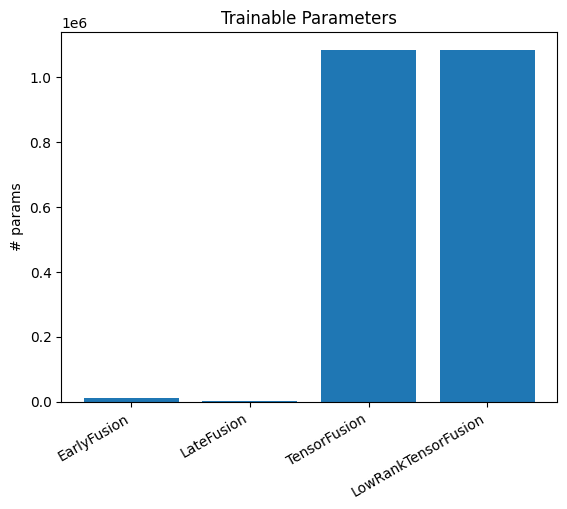

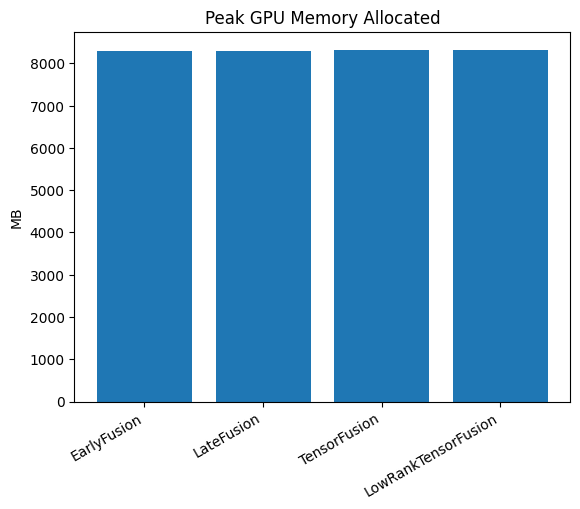

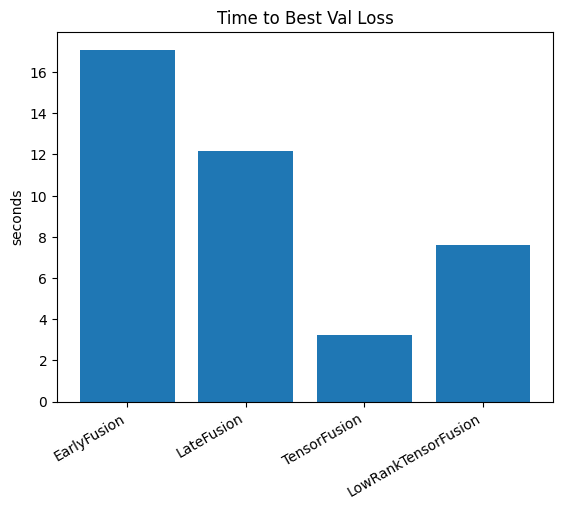

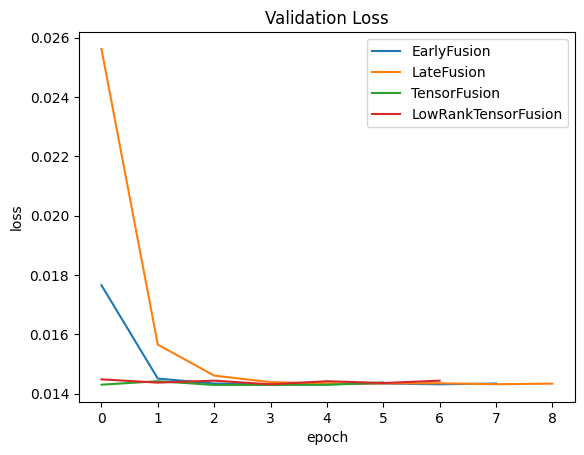

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

names = [r["name"] for r in results]
params = [r["trainable_params"] for r in results]
mem = [r["peak_mem_mb"] if r["peak_mem_mb"] is not None else 0 for r in results]
tbest = [r["time_to_best_sec"] if r["time_to_best_sec"] is not None else np.nan for r in results]

plt.figure()
plt.bar(names, params)
plt.xticks(rotation=30, ha="right")
plt.title("Trainable Parameters")
plt.ylabel("# params")
plt.show()

plt.figure()
plt.bar(names, mem)
plt.xticks(rotation=30, ha="right")
plt.title("Peak GPU Memory Allocated")
plt.ylabel("MB")
plt.show()

plt.figure()
plt.bar(names, tbest)
plt.xticks(rotation=30, ha="right")
plt.title("Time to Best Val Loss")
plt.ylabel("seconds")
plt.show()

#loss curves
plt.figure()
for r in results:
    plt.plot(r["val_loss"], label=r["name"])
plt.title("Validation Loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

(10 points) In addition, create some visualizations of the following for each fusion:

* Number of parameters for each model (unimodal and multimodal)
* Memory Use
* Time until convergence

You are free to plot them here or through other means (like wandb). After doing so, discuss what are the pros and cons of unimodal versus multimodal models.

# Problem 6: Contrastive Learning (30 points)

For the next part of this HW, we will focus on contrastive learning. As a reminder, contrastive learning is a local, discrete alignment method used in machine learning. To explore this, we look at [CLIP](https://arxiv.org/pdf/2103.00020), a multimodal model developed by OpenAI that uses contrastive learning to align visual and textual data together.

**THIS IS JUST AN EXAMPLE, DO NOT LET THIS RESTRICT THE IMPLEMENTATION YOU WILL BE DOING.**

In [ ]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.1 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-3jfibesc
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-3jfibesc
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=e0235470c505f93050d672d74b7f9e8d58e1231cab417e89e46f48592fcffd59
  Stored in directory: /tmp/pip-ephem-wheel-cache-49p5wo1w/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [ ]:
# Packages to import
import transformers
import torch
import clip
from PIL import Image
import requests
from io import BytesIO

First, we create the model.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading CLIP on {device}...")
model, preprocess = clip.load("ViT-B/32", device=device)

Loading CLIP on cuda...


100%|███████████████████████████████████████| 338M/338M [00:03<00:00, 89.1MiB/s]


Next, we will load an image to use. Note that we cannot use the MOSI dataset - we need to use raw data and the data points from the dataset already have extracted features. Upload a picture of someone smiling to use for this example (you can just find one online, save it and add to here).

In [ ]:
%%bash
pwd

In [ ]:
image_filename = "/content/drive/MyDrive/MEng/6.S985/smiling_person.jpg" # REPLACE WITH YOUR FILE
image = Image.open(image_filename).convert("RGB")

Now, we will prepare the prompt to use.

In [ ]:
# Options to pick from
text_options = ["a photo of a sad person", "a photo of a happy person", "a photo of an angry person"]
image_input = preprocess(image).unsqueeze(0).to(device)
text_inputs = clip.tokenize(text_options).to(device)

Now, let's run the inference and get the results!

In [ ]:
with torch.no_grad():
    image_features = model.encode_image(image_input)
    text_features = model.encode_text(text_inputs)

    # Normalize features
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # Calculate similarity (Dot Product)
    similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
    values, indices = similarity[0].topk(3)

print(f"\nImage classified against: {text_options}")
print("-" * 30)
for value, index in zip(values, indices):
    print(f"{text_options[index]:>30s}: {100 * value.item():.2f}%")


Image classified against: ['a photo of a sad person', 'a photo of a happy person', 'a photo of an angry person']
------------------------------
     a photo of a happy person: 90.82%
       a photo of a sad person: 6.89%
    a photo of an angry person: 2.31%


(10 pts) We will now create, train and run zero-shot classification using contrastive learning for your own dataset. Fill in the missing information below for a generalize contrastive learning model. The training and zero-shot classification functions have been provided to you, through you may need to make slight modifications based on your dataset setup. **Design the model keeping in mind the modalities that you are specifically using. THE CLIP EXAMPLE ABOVE IS JUST TO SHOW CONTRASTIVE LEARNING IN ACTION - WE ARE NOT REQUIRING THAT YOU USE TEXT AND IMAGE AS THE MODALITIES OF CHOICE.** Try various queries, projectors, and settings on your dataset!

**You must use einsum where applicable.**


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# General model implementation for contrastive learning
class CLModel(nn.Module):
  def __init__(self, dim_x1, dim_x2, embedded_dim=64, temp=.07, hidden=128, dropout=0.1):
    super().__init__()
    # TODO:
    # 1. Create Encoders for modalities
    # 2. Create a projector, which maps specific modality dimensions to a shared space.
    #     do this for each modality. (hint: fusions!)
    # 3. Create learnable temperature (this has already been done for you)

    # 1) Encoders (map raw features -> hidden)
    self.enc1 = nn.Sequential(
        nn.Linear(dim_x1, hidden),
        nn.ReLU(),
        nn.Dropout(dropout),
    )
    self.enc2 = nn.Sequential(
        nn.Linear(dim_x2, hidden),
        nn.ReLU(),
        nn.Dropout(dropout),
    )

    # 2) Projectors (hidden -> shared embedding space)
    self.proj1 = nn.Sequential(
        nn.Linear(hidden, embedded_dim),
    )
    self.proj2 = nn.Sequential(
        nn.Linear(hidden, embedded_dim),
    )

    # 3) Learnable logit scale (temperature); template already suggested this form
    # scale is log(1/temp) so exp(scale) = 1/temp
    self.logit_scale = nn.Parameter(torch.ones([]) * torch.log(torch.tensor(1.0 / temp)))


  def forward(self, x1, x2):
    # TODO:
    # 1. Extract the raw features
    # 2. Project them to the embedding space
    # 3. Normalize vectors and return

    # YOUR CODE HERE
    # x1: (B, dim_x1)  EEG features
    # x2: (B, dim_x2)  ECG features

    h1 = self.enc1(x1)          # (B, hidden)
    h2 = self.enc2(x2)          # (B, hidden)

    z1 = self.proj1(h1)         # (B, embedded_dim)
    z2 = self.proj2(h2)         # (B, embedded_dim)

    # Normalize so dot product == cosine similarity
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    return z1, z2

# Contrastive loss. This pulls positives together and pulls negatives apart
class ContrastiveLoss(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, x1_emb, x2_emb):
        """
        x1_emb: (B, D) normalized EEG embeddings
        x2_emb: (B, D) normalized ECG embeddings
        """
        # scale = exp(logit_scale) = 1/temp (learnable)
        scale = self.model.logit_scale.exp()

        # similarity logits: (B, B)
        logits = scale * torch.einsum("bd,cd->bc", x1_emb, x2_emb)

        labels = torch.arange(logits.size(0), device=logits.device)

        loss_i = self.loss_fn(logits, labels)      # EEG -> ECG
        loss_j = self.loss_fn(logits.T, labels)    # ECG -> EEG
        return 0.5 * (loss_i + loss_j)



In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class EEGECGAlignedPairs(Dataset):
    def __init__(self, x_eeg, x_ecg):
        """
        x_eeg: torch.FloatTensor [N, 18]
        x_ecg: torch.FloatTensor [N, 4]
        Assumes index i in EEG aligns with index i in ECG (positive pairs).
        """
        assert x_eeg.shape[0] == x_ecg.shape[0]
        self.x_eeg = x_eeg
        self.x_ecg = x_ecg

    def __len__(self):
        return self.x_eeg.shape[0]

    def __getitem__(self, idx):
        return self.x_eeg[idx], self.x_ecg[idx]   # (data_a, data_b)

def make_cl_dataloader(x_eeg, x_ecg, batch_size=512, shuffle=True, num_workers=0):
    ds = EEGECGAlignedPairs(x_eeg, x_ecg)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=num_workers, drop_last=True)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# x_eeg: [N, 18], x_ecg: [N, 4] on CPU is fine; train_model moves to device
cl_loader = make_cl_dataloader(x_eeg, x_ecg, batch_size=512, shuffle=True)

In [ ]:
import torch.optim as optim
# Training function
def train_model(model, contrastive_loss, dataloader, num_epochs=5, learning_rate=3e-4, device='cpu'):

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    model.to(device)
    model.train()
    print(f"Starting training for {num_epochs} epochs...")

    for epoch in range(num_epochs):
        epoch_loss = 0.0

        for batch_idx, (data_a, data_b) in enumerate(dataloader):
            data_a, data_b = data_a.to(device), data_b.to(device)

            optimizer.zero_grad()

            emb_a, emb_b = model(data_a, data_b)

            loss = contrastive_loss(emb_a, emb_b)

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)
        print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f}")

In [ ]:
embedded_dim = 64
temp = 0.07  # common starting point

model = CLModel(dim_x1=18, dim_x2=4, embedded_dim=embedded_dim, temp=temp)
contrastive_loss = ContrastiveLoss(model)   # if your class expects model

train_model(
    model=model,
    contrastive_loss=contrastive_loss,
    dataloader=cl_loader,
    num_epochs=10,
    learning_rate=3e-4,
    device=device
)

Starting training for 10 epochs...
Epoch [1/10] | Loss: 6.2429
Epoch [2/10] | Loss: 6.2388
Epoch [3/10] | Loss: 6.2386
Epoch [4/10] | Loss: 6.2385
Epoch [5/10] | Loss: 6.2385
Epoch [6/10] | Loss: 6.2385
Epoch [7/10] | Loss: 6.2384
Epoch [8/10] | Loss: 6.2384
Epoch [9/10] | Loss: 6.2384
Epoch [10/10] | Loss: 6.2384


In [ ]:
# After training, we can now do zero-shot prediction
@torch.no_grad()
def predict_best_match(model, query_input, candidate_inputs, device):
    model.eval()

    query_feat = model.enc1(query_input.unsqueeze(0).to(device))
    query_emb = F.normalize(model.proj1(query_feat), dim=1)

    cand_feat = model.enc2(candidate_inputs.to(device))
    cand_emb = F.normalize(model.proj2(cand_feat), dim=1)

    scores = torch.einsum('id, jd -> ij', query_emb, cand_emb)

    best_match_idx = scores.argmax().item()

    print(f"Best match: {best_match_idx} with score {scores[0, best_match_idx].item()}")

    return best_match_idx, scores


import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

# pick one index as query
i = 0
query_input = x_eeg[i]                 # (18,)

# choose K candidate ECGs (including the true one at i)
K = 128
perm = torch.randperm(x_ecg.shape[0])
cand_idxs = perm[:K]

# force the true match to be in the candidates
cand_idxs[0] = i

candidate_inputs = x_ecg[cand_idxs]    # (K, 4)

best_idx, scores = predict_best_match(
    model,
    query_input=query_input,
    candidate_inputs=candidate_inputs,
    device=device
)

print("Best candidate position:", best_idx)
print("True match position should be 0 (because cand_idxs[0] set to i)")
print("Was it correct?", best_idx == 0)

Best match: 16 with score 0.08508861809968948
Best candidate position: 16
True match position should be 0 (because cand_idxs[0] set to i)
Was it correct? False


Now answer some of these questions:

1. (5 points) Any suprising results from using this on your dataset?

For this one example, the model did not perform well and didn't guess the correct ECG segment that aligned with the EEG segment. I am not sure if this is possibly surprising since the EEG and ECG should be aligned, but it may also be very hard to tell given that our model is no the most expressive/fine-tuned for this specific task. Additionally, they might not align because we have 18 features for EEG and 4 for ECG; even if they are time-aligned, they might not have the strongest amount of information shared at this level of features we have extracted.

2. (5 points) Typically, cross-entropy loss is used in this contrastive learning, why is this the case?

We use cross-entropy loss for contrastive learning because our model predicts the probability and our window from modality one is assigned to each other data window with a given probability, where there is one true assignment. For the EEG modality, we compute similarity scores toa ll the candidate ECG embeddings, and then apply the softmax function to obtain a probability distribution over the candidates. Cross-entropy is a good loss to use because it evaluates all possible pairs/matches. In this way it's a classification task, so we use cross-entropy loss.

3. (10 points) Create some visual examples of the data post alignment. Can you point out samples where the alignment worked and where it failed? Why do you suspect that is?

From the plot below, it seems there are more failures than alignment successes. The embeddings may have collapsed or are at least not very discriminative. This may be due to too few training epochs, learning rate issues, small batch sizes, or the fact that the features themselves don’t contain enough alignment signal. I suspect part of it is the number of epochs I trained on and the amount of patient data I had, which was only 3 patients. ECG data also contains a lot of near-duplicates, since the features are very similar across time, so many indices have similar embeddings and are hard to discriminate/associate with a given EEG window.

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

@torch.no_grad()
def retrieval_for_query(model, x_eeg, x_ecg, query_idx, device="cpu"):
    """
    x_eeg: torch.Tensor [N, 18]
    x_ecg: torch.Tensor [N, 4]
    query_idx: int
    Returns: pred_idx, scores (N,), query_emb (D,), cand_embs (N, D)
    """
    model.eval()
    model.to(device)

    # Encode query EEG
    q_x = x_eeg[query_idx].unsqueeze(0).to(device)   # [1, 18]
    q_h = model.enc1(q_x)
    q_emb = F.normalize(model.proj1(q_h), dim=1)     # [1, D]

    # Encode all candidate ECG
    c_x = x_ecg.to(device)                           # [N, 4]
    c_h = model.enc2(c_x)
    c_emb = F.normalize(model.proj2(c_h), dim=1)     # [N, D]

    # Similarity scores (dot product == cosine similarity since normalized)
    scores = torch.einsum("id,jd->ij", q_emb, c_emb).squeeze(0)  # [N]

    pred_idx = int(torch.argmax(scores).item())
    return pred_idx, scores.detach().cpu(), q_emb.detach().cpu(), c_emb.detach().cpu()

In [ ]:
def plot_alignment_example(x_eeg, x_ecg, query_idx, pred_idx, scores, title=""):
    """
    x_eeg: [N,18] tensor or numpy
    x_ecg: [N,4]
    scores: [N]
    """
    # move to cpu + numpy for plotting
    xe = x_eeg.detach().cpu().numpy() if torch.is_tensor(x_eeg) else x_eeg
    xc = x_ecg.detach().cpu().numpy() if torch.is_tensor(x_ecg) else x_ecg
    sc = scores.detach().cpu().numpy() if torch.is_tensor(scores) else scores

    true_idx = query_idx
    ok = (pred_idx == true_idx)

    fig = plt.figure(figsize=(12, 8))

    # EEG features (18)
    ax1 = plt.subplot2grid((3, 2), (0, 0))
    ax1.plot(xe[query_idx], marker="o")
    ax1.set_title(f"EEG features @ idx={query_idx}")
    ax1.set_xlabel("feature dim")
    ax1.set_ylabel("value")

    # True ECG features (4)
    ax2 = plt.subplot2grid((3, 2), (0, 1))
    ax2.bar(range(len(xc[true_idx])), xc[true_idx])
    ax2.set_title(f"True ECG features @ idx={true_idx}")
    ax2.set_xlabel("feature dim")
    ax2.set_ylabel("value")

    # Pred ECG features (4)
    ax3 = plt.subplot2grid((3, 2), (1, 1))
    ax3.bar(range(len(xc[pred_idx])), xc[pred_idx])
    ax3.set_title(f"Pred ECG features @ idx={pred_idx}  ({'CORRECT' if ok else 'WRONG'})")
    ax3.set_xlabel("feature dim")
    ax3.set_ylabel("value")

    # Similarity scores across all candidates
    ax4 = plt.subplot2grid((3, 2), (1, 0), rowspan=2, colspan=2)
    ax4.plot(sc)
    ax4.axvline(true_idx, linestyle="--")
    ax4.axvline(pred_idx, linestyle="--")
    ax4.set_title("Similarity scores vs candidate ECG index (dashed: true / pred)")
    ax4.set_xlabel("candidate index")
    ax4.set_ylabel("similarity")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

In [ ]:
import random

def find_success_fail_examples(model, x_eeg, x_ecg, device="cpu", num_to_find=3, max_tries=200):
    N = x_eeg.shape[0]
    indices = list(range(N))
    random.shuffle(indices)

    successes, failures = [], []
    tries = 0

    for q in indices:
        pred_idx, scores, _, _ = retrieval_for_query(model, x_eeg, x_ecg, q, device=device)
        if pred_idx == q and len(successes) < num_to_find:
            successes.append((q, pred_idx, scores))
        if pred_idx != q and len(failures) < num_to_find:
            failures.append((q, pred_idx, scores))

        tries += 1
        if tries >= max_tries or (len(successes) == num_to_find and len(failures) == num_to_find):
            break

    return successes, failures

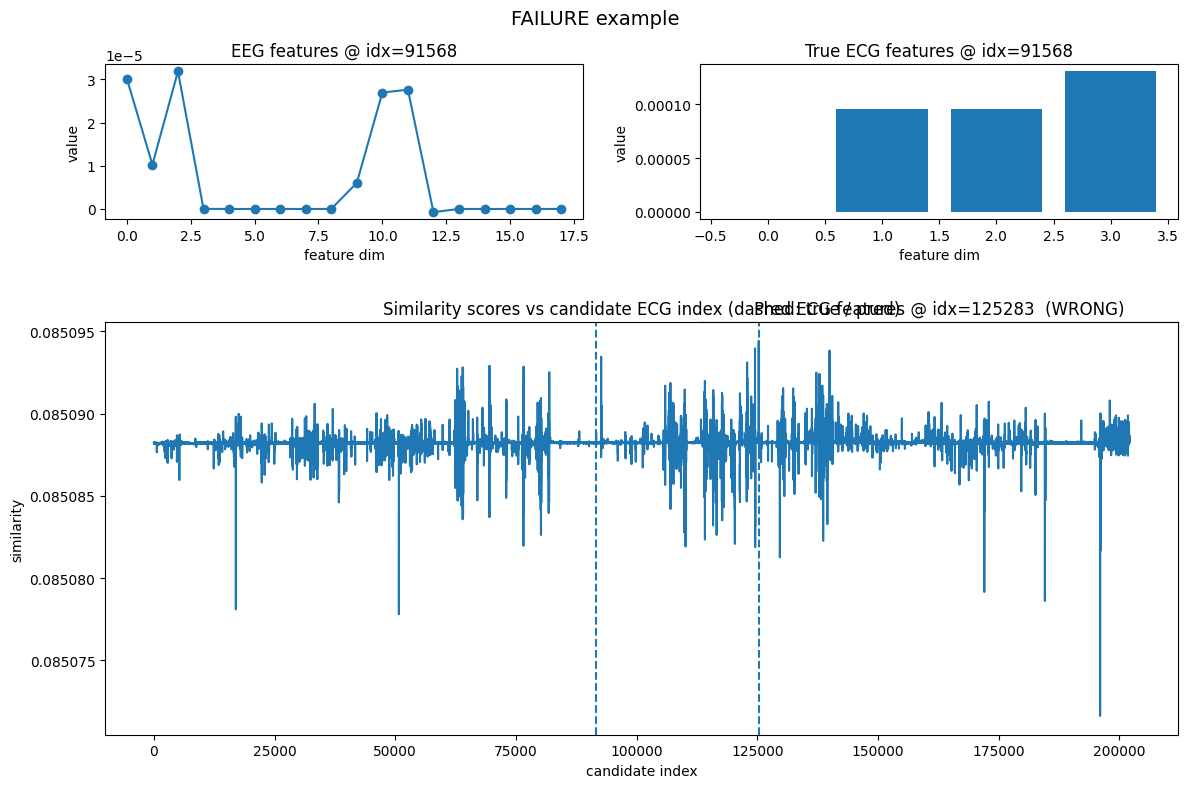

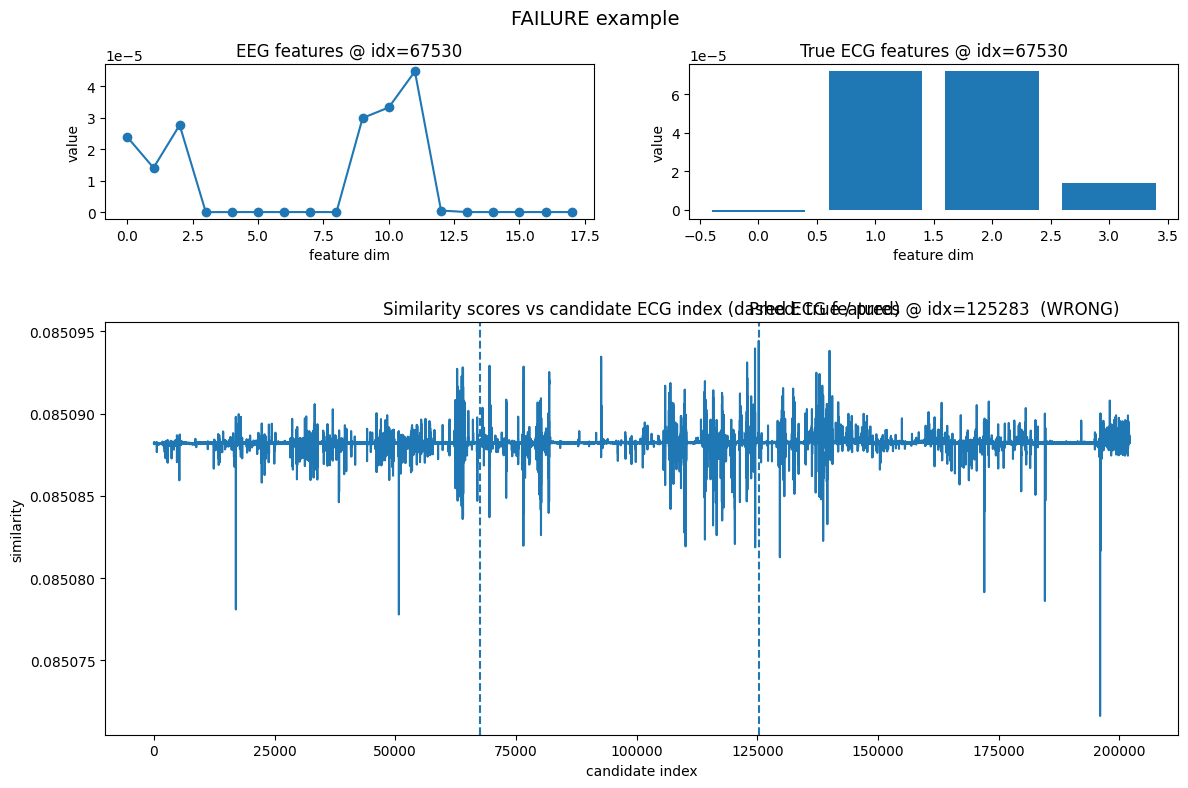

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

successes, failures = find_success_fail_examples(model, x_eeg, x_ecg, device=device, num_to_find=2)

for (q, pred, scores) in successes:
    plot_alignment_example(x_eeg, x_ecg, q, pred, scores, title="SUCCESS example")

for (q, pred, scores) in failures:
    plot_alignment_example(x_eeg, x_ecg, q, pred, scores, title="FAILURE example")

# Problem 7: Reflection (10 points)

Now we'll take some time to reflect on this homework. Take some time to discuss the following:

1. (5 points) What concept did you find the most interesting?

I found the idea of mid-level fusion most interesting! It sounded very daunting when we learned about it, but after implementing it I realized it was not as scary/intimidating as I thought it would be. It is very related to the other fusion methods and I found I understood the differences once I implemented it.

2. (5 points) Which concepts (if any) do you see being useful towards your goal? Why? If there was none, discuss why.

The concepts of pros/cons for early and late fusion are very helpful for my goal of fusing EEG and ECG data. There are clearly upsides and downsides to both, and I hope to spend some time understanding what the best approach is for my specific dataset. I think it's an interesting process learning about the fusion method in relation to my dataset, because EEG and ECG are unique modalities that interact with fusion methods differently.

3. (0 points, optional) Is there a topic that was discussed during lectures up to the release of the assignment that you wished was covered in the homework? Any from the assignment that you wanted there to be touched upon more? Any feedback you have in general for homeworks or the class?